## Neural Networks - Deep Learning
**Theodora Tzina - AEM: 10715**
### Exercise 3
#### ***Part A: Autoencoder – Simple Reconstruction***

This notebook implements various autoencoder architectures for MNIST digit reconstruction and compares them with PCA. A simple CNN digit classifier is applied to reconstructed images.

In [1]:
import numpy as np
import time
import tensorflow as tf
from keras import layers, Model
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Reshape, Flatten, BatchNormalization
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import dataProccessing as dp

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

**MNIST dataset preparation**

In [2]:
# Load and normalize MNIST dataset
x_train, y_train, x_test, y_test = dp.load_mnist()

# Flatten MNIST images
x_train, x_test = dp.flatten_mnist(x_train, x_test)

# Load MNIST classes
mnist_classes = dp.get_class_names()

# Get one example of each digit from the test set
test_indices = dp.get_stratified_samples(y_test, n_per_class=1)
test_samples = x_test[test_indices]

Loading and Normalizing MNIST Dataset
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)

Flattening MNIST images
Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)

MNIST Classes
0: 0
1: 1
2: 2
3: 3
4: 4
5: 5
6: 6
7: 7
8: 8
9: 9



#### **Model 1: Simple Dense Autoencoder**
A basic autoencoder with few Dense layers and small encoding dimension.


Training Model 1...

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0719 - val_loss: 0.0445
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0363 - val_loss: 0.0299
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0259 - val_loss: 0.0232
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0215 - val_loss: 0.0207
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0195 - val_loss: 0.0190
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0179 - val_loss: 0.0175
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0164 - val_loss: 0.0160
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0151 - val_loss: 0.0149
Epoch 9/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0142 - val_loss: 0.0142
Epoch 10/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0136 - val_loss: 0.0137
Epoch 11/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0131 - val_loss: 0.0133
Epoch 12/50
141/141 ━━━━━━━━━━

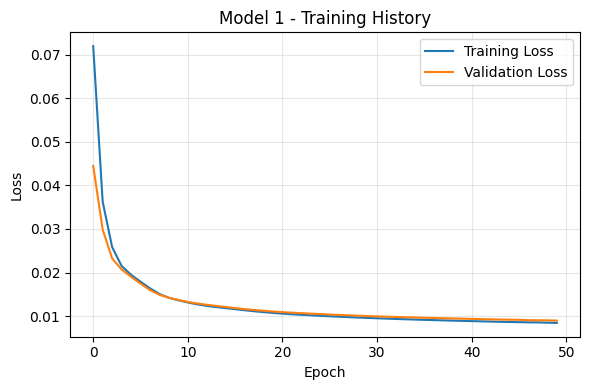

Model 1 Final Validation Loss: 0.008981
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


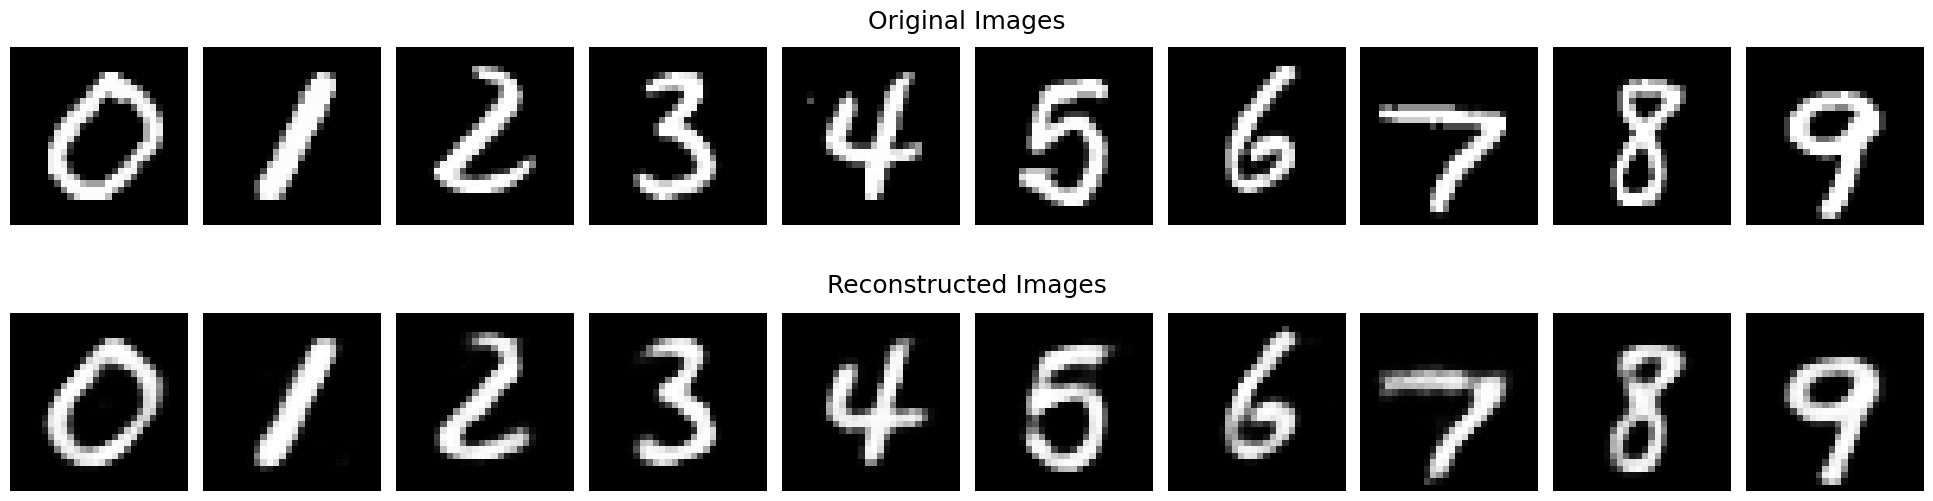

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step
Model 1 Test MSE: 0.008539


In [3]:
# Model 1: Simple Autoencoder with small encoding
encoding_dim = 32

# Encoder
encoder_input = layers.Input(shape=(784,))
x = layers.Dense(128, activation='relu')(encoder_input)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_1 = Model(encoder_input, latent, name='encoder_1')

# Decoder
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(128, activation='relu')(decoder_input)
decoder_output = layers.Dense(784, activation='sigmoid')(x)

decoder_1 = Model(decoder_input, decoder_output, name='decoder_1')

# Autoencoder Model
autoencoder_1 = Model(encoder_input, decoder_1(encoder_1(encoder_input)), name='autoencoder_1')
autoencoder_1.compile(optimizer='adam', loss='mse')

# Train the model
print("\nTraining Model 1...\n")
start_time = time.time()
history_1 = autoencoder_1.fit(x_train, x_train, epochs=50,
            batch_size=256, validation_split=0.4, verbose=1)
train_time_1 = time.time() - start_time
print(f"\nModel 1 Training Time: {train_time_1:.2f} seconds")

# Plot training history
dp.plot_history(history_1, "Model 1")

# Store validation loss
val_loss_1 = history_1.history['val_loss'][-1]
print(f"Model 1 Final Validation Loss: {val_loss_1:.6f}")

# Visualize reconstructions on test set
reconstructed_1 = autoencoder_1.predict(test_samples)
dp.plot_reconstructions(test_samples, reconstructed_1, n=10)

# Calculate test MSE loss
mse_1 = dp.calculate_mse(x_test, autoencoder_1.predict(x_test))
print(f"Model 1 Test MSE: {mse_1:.6f}")

#### **Model 2: Deeper Dense Autoencoder**
Adding more Dense layers and icreasing encoding dimension.


Training Model 2...

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0690 - val_loss: 0.0401
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0314 - val_loss: 0.0260
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0228 - val_loss: 0.0210
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0187 - val_loss: 0.0179
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0161 - val_loss: 0.0156
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0144 - val_loss: 0.0144
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0133 - val_loss: 0.0131
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0123 - val_loss: 0.0123
Epoch 9/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0114 - val_loss: 0.0115
Epoch 10/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0107 - val_loss: 0.0109
Epoch 11/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0102 - val_loss: 0.0106
Epoch 12/50
141/141

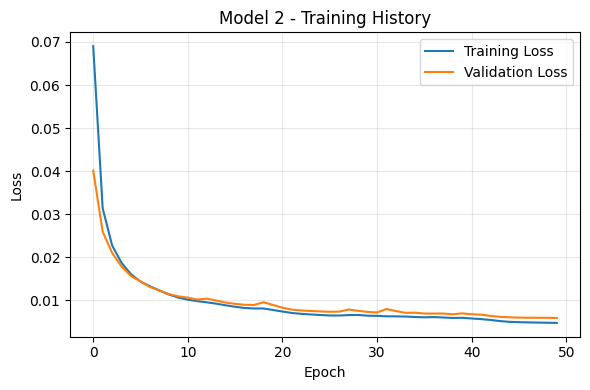

Model 2 Final Validation Loss: 0.005913
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


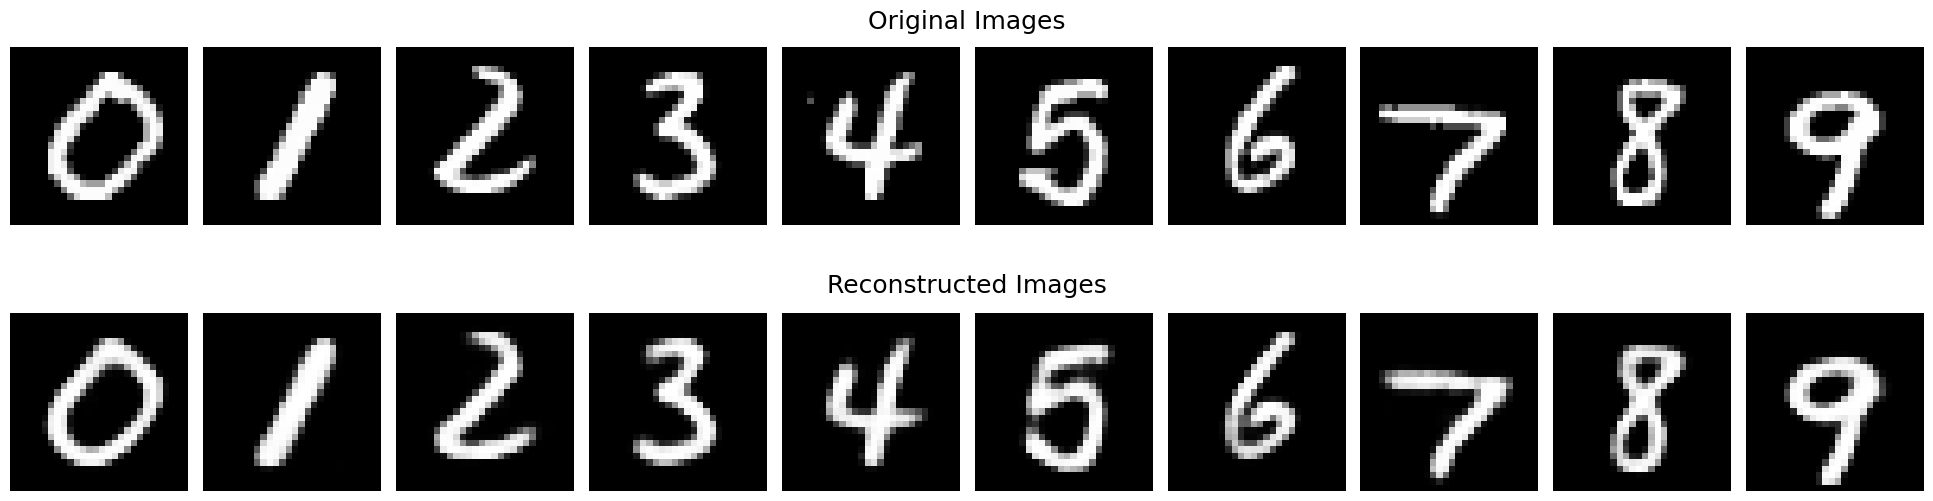

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model 2 Test MSE: 0.005632


In [4]:
# Model 2: Deeper Autoencoder with larger encoding
encoding_dim = 64

# Encoder
encoder_input = layers.Input(shape=(784,))
x = layers.Dense(512, activation='relu')(encoder_input)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_2 = Model(encoder_input, latent, name='encoder_2')

# Decoder
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(128, activation='relu')(decoder_input)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(512, activation='relu')(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)

decoder_2 = Model(decoder_input, decoder_output, name='decoder_2')

# Autoencoder Model
autoencoder_2 = Model(encoder_input, decoder_2(encoder_2(encoder_input)), name='autoencoder_2')
autoencoder_2.compile(optimizer='adam', loss='mse')

# Train the model
print("\nTraining Model 2...\n")
start_time = time.time()
history_2 = autoencoder_2.fit(x_train, x_train, epochs=50,
            batch_size=256, validation_split=0.4, verbose=1)
train_time_2 = time.time() - start_time
print(f"\nModel 2 Training Time: {train_time_2:.2f} seconds")

# Plot training history
dp.plot_history(history_2, "Model 2")

# Store validation loss
val_loss_2 = history_2.history['val_loss'][-1]
print(f"Model 2 Final Validation Loss: {val_loss_2:.6f}")

# Get 

# Visualize reconstructions on test set
reconstructed_2 = autoencoder_2.predict(test_samples)
dp.plot_reconstructions(test_samples, reconstructed_2, n=10)

# Calculate test MSE
mse_2 = dp.calculate_mse(x_test, autoencoder_2.predict(x_test))
print(f"Model 2 Test MSE: {mse_2:.6f}")


#### **Model 3: Larger bottleneck Autoencoder**
Using the same Dense layers for even larger encoding dimension.


Training Model 3...

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0580 - val_loss: 0.0273
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0208 - val_loss: 0.0166
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0144 - val_loss: 0.0134
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0118 - val_loss: 0.0115
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0103 - val_loss: 0.0102
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0093 - val_loss: 0.0092
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0085 - val_loss: 0.0085
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0081 - val_loss: 0.0083
Epoch 9/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0076 - val_loss: 0.0079
Epoch 10/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0071 - val_loss: 0.0075
Epoch 11/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0066 - val_loss: 0.0070
Epoch 12/50
141/141

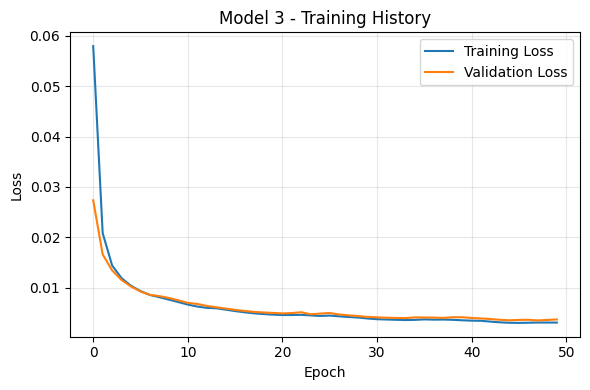

Model 3 Final Validation Loss: 0.003661
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


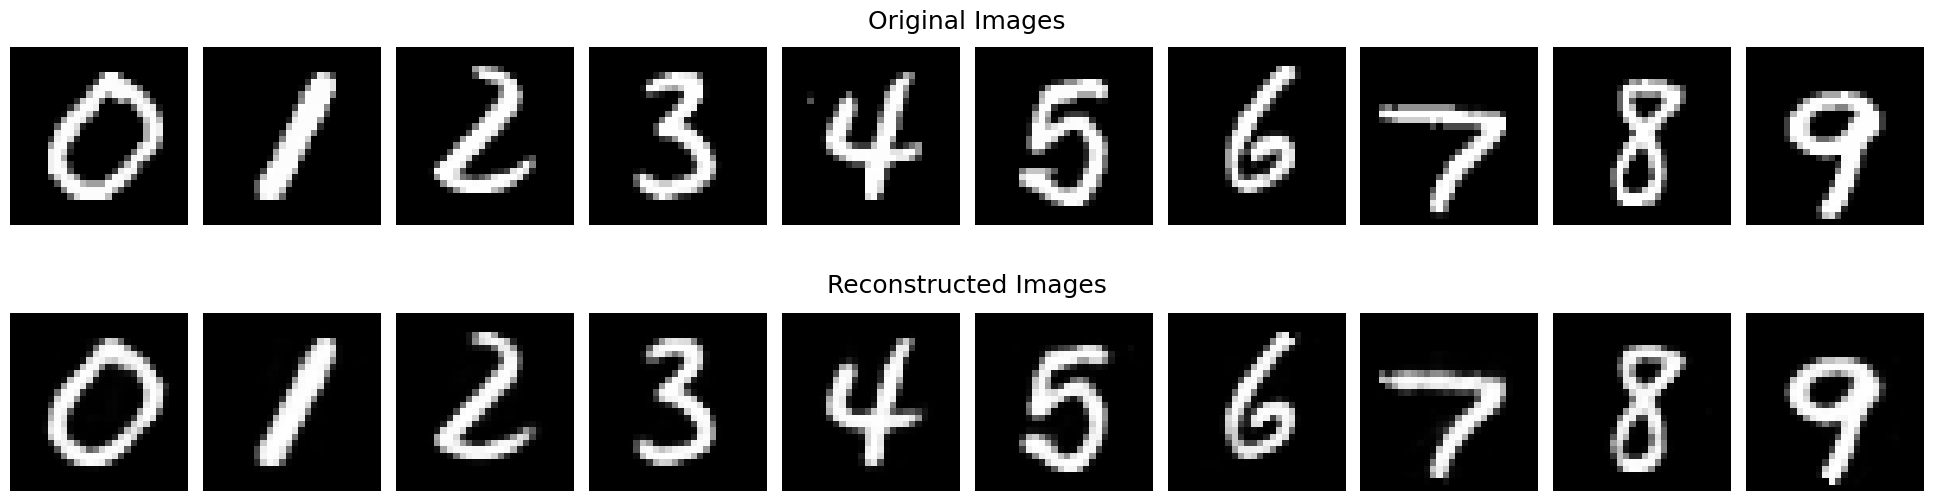

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model 3 Test MSE: 0.003495


In [5]:
# Model 3: Deeper Autoencoder with larger encoding
encoding_dim = 128

# Encoder
encoder_input = layers.Input(shape=(784,))
x = layers.Dense(512, activation='relu')(encoder_input)
x = layers.Dense(256, activation='relu')(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_3 = Model(encoder_input, latent, name='encoder_3')

# Decoder
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(256, activation='relu')(decoder_input)
x = layers.Dense(512, activation='relu')(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)

decoder_3 = Model(decoder_input, decoder_output, name='decoder_3')

# Autoencoder Model
autoencoder_3 = Model(encoder_input, decoder_3(encoder_3(encoder_input)), name='autoencoder_3')
autoencoder_3.compile(optimizer='adam', loss='mse')

# Train the model
print("\nTraining Model 3...\n")
start_time = time.time()
history_3 = autoencoder_3.fit(x_train, x_train, epochs=50,
            batch_size=256, validation_split=0.4, verbose=1)
train_time_3 = time.time() - start_time
print(f"\nModel 3 Training Time: {train_time_3:.2f} seconds")

# Plot training history
dp.plot_history(history_3, "Model 3")

# Store validation loss
val_loss_3 = history_3.history['val_loss'][-1]
print(f"Model 3 Final Validation Loss: {val_loss_3:.6f}")

# Visualize reconstructions on test set
reconstructed_3 = autoencoder_3.predict(test_samples)
dp.plot_reconstructions(test_samples, reconstructed_3, n=10)

# Calculate test MSE
mse_3 = dp.calculate_mse(x_test, autoencoder_3.predict(x_test))
print(f"Model 3 Test MSE: {mse_3:.6f}")

#### **Model 4: Autoencoder with extra metrics**

Using the same Dense layers and encoding dimension but training with PSNR, SSIM metrics.


Training Model 4...

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.0592 - psnr: 13.1285 - ssim: 0.3573 - val_loss: 0.0301 - val_psnr: 15.6923 - val_ssim: 0.6093
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0219 - psnr: 17.2272 - ssim: 0.7200 - val_loss: 0.0174 - val_psnr: 18.2203 - val_ssim: 0.7771
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0150 - psnr: 18.8976 - ssim: 0.8159 - val_loss: 0.0135 - val_psnr: 19.3543 - val_ssim: 0.8357
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0122 - psnr: 19.7968 - ssim: 0.8549 - val_loss: 0.0117 - val_psnr: 20.0051 - val_ssim: 0.8664
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0108 - psnr: 20.3751 - ssim: 0.8747 - val_loss: 0.0105 - val_psnr: 20.5081 - val_ssim: 0.8777
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0096 - psnr: 20.8759 - ssim: 0.8890 - val_loss: 0.0095 - val_psnr: 20.9370 - val_ssim: 0.8937
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━

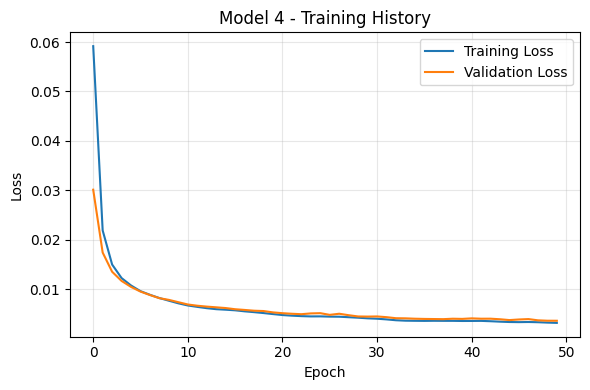

Model 4 Final Validation Loss: 0.003616
Model 4 Final Validation PSNR: 25.728479
Model 4 Final Validation SSIM: 0.960668
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


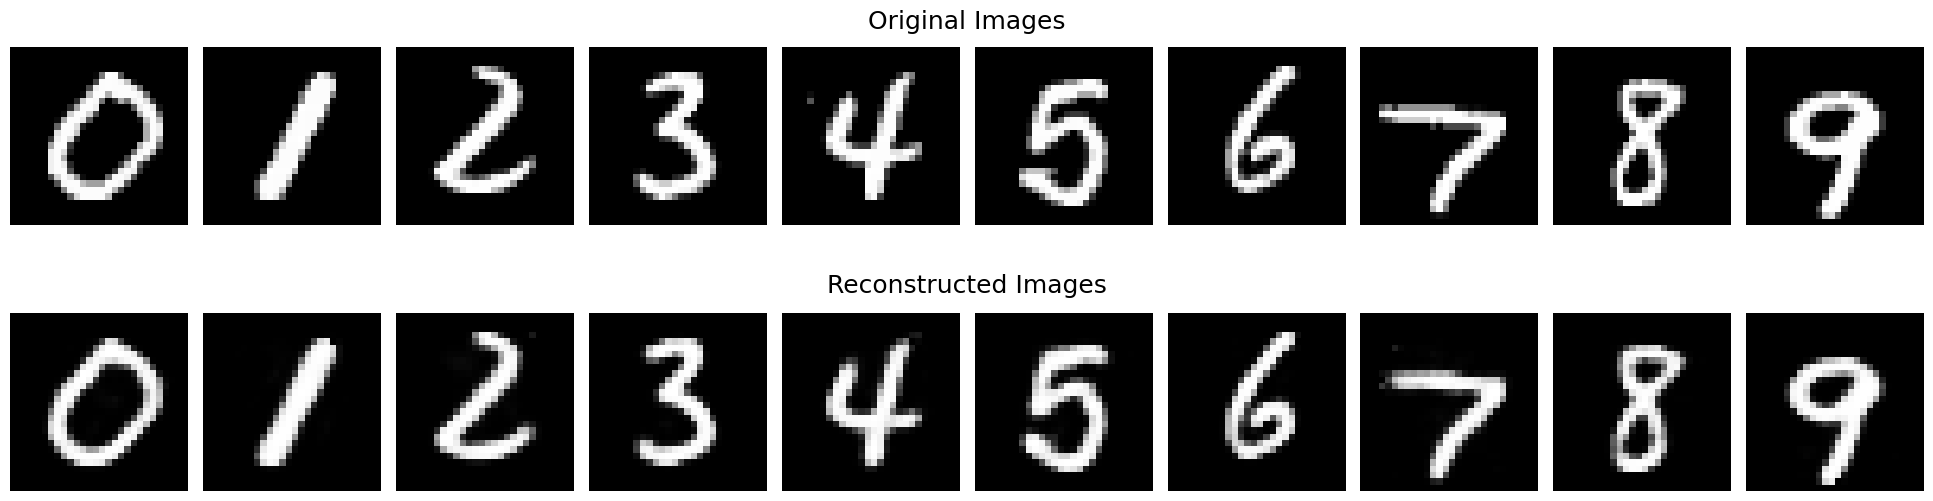

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model 4 Test MSE: 0.003453


In [6]:
# Model 4: Deeper Autoencoder with larger encoding
encoding_dim = 128

# Encoder
encoder_input = layers.Input(shape=(784,))
x = layers.Dense(512, activation='relu')(encoder_input)
x = layers.Dense(256, activation='relu')(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_4 = Model(encoder_input, latent, name='encoder_4')

# Decoder
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(256, activation='relu')(decoder_input)
x = layers.Dense(512, activation='relu')(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)

decoder_4 = Model(decoder_input, decoder_output, name='decoder_4')

# Autoencoder Model
autoencoder_4 = Model(encoder_input, decoder_4(encoder_4(encoder_input)), name='autoencoder_4')
autoencoder_4.compile(optimizer='adam', loss='mse', metrics=[dp.psnr, dp.ssim])

# Train the model
print("\nTraining Model 4...\n")
start_time = time.time()
history_4 = autoencoder_4.fit(x_train, x_train, epochs=50,
            batch_size=256, validation_split=0.4, verbose=1)
train_time_4 = time.time() - start_time
print(f"\nModel 4 Training Time: {train_time_4:.2f} seconds")

# Plot training history
dp.plot_history(history_4, "Model 4")

# Store validation loss
val_loss_4 = history_4.history['val_loss'][-1]
val_psnr_4 = history_4.history['psnr'][-1]
val_ssim_4 = history_4.history['ssim'][-1]
print(f"Model 4 Final Validation Loss: {val_loss_4:.6f}")
print(f"Model 4 Final Validation PSNR: {val_psnr_4:.6f}")
print(f"Model 4 Final Validation SSIM: {val_ssim_4:.6f}")

# Visualize reconstructions on test set
reconstructed_4 = autoencoder_4.predict(test_samples)
dp.plot_reconstructions(test_samples, reconstructed_4, n=10)

# Calculate test MSE
mse_4 = dp.calculate_mse(x_test, autoencoder_4.predict(x_test))
print(f"Model 4 Test MSE: {mse_4:.6f}")

#### **Model 5: Convolutional Autoencoder**
Using convolutional layers for spatial feature extraction.


Training Model 5 (Convolutional)...

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 91s 616ms/step - loss: 0.0370 - psnr: 16.6671 - ssim: 0.5643 - val_loss: 0.0689 - val_psnr: 11.9049 - val_ssim: 0.1891
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 89s 632ms/step - loss: 0.0063 - psnr: 22.6339 - ssim: 0.8235 - val_loss: 0.0315 - val_psnr: 15.2660 - val_ssim: 0.5792
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 88s 621ms/step - loss: 0.0045 - psnr: 24.0536 - ssim: 0.8749 - val_loss: 0.0086 - val_psnr: 20.9987 - val_ssim: 0.8485
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 83s 588ms/step - loss: 0.0038 - psnr: 24.7446 - ssim: 0.9012 - val_loss: 0.0049 - val_psnr: 23.4658 - val_ssim: 0.8984
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 83s 587ms/step - loss: 0.0034 - psnr: 25.3009 - ssim: 0.9182 - val_loss: 0.0041 - val_psnr: 24.2773 - val_ssim: 0.9166
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 89s 634ms/step - loss: 0.0030 - psnr: 25.7245 - ssim: 0.9302 - val_loss: 0.0037 - val_psnr: 24.8787 - val_ssim: 0.9302
Epoch 7/

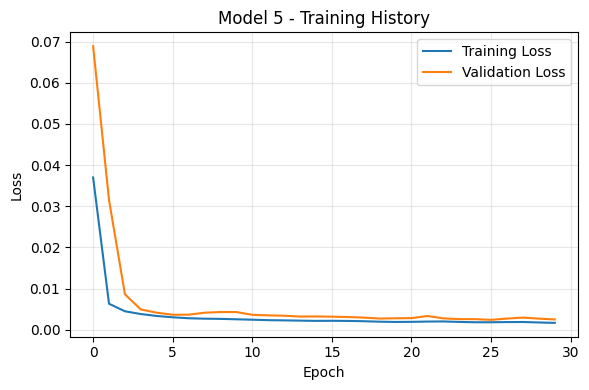

Model 5 Final Validation Loss: 0.002515
Model 5 Final Validation PSNR: 28.198368
Model 5 Final Validation SSIM: 0.971523
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


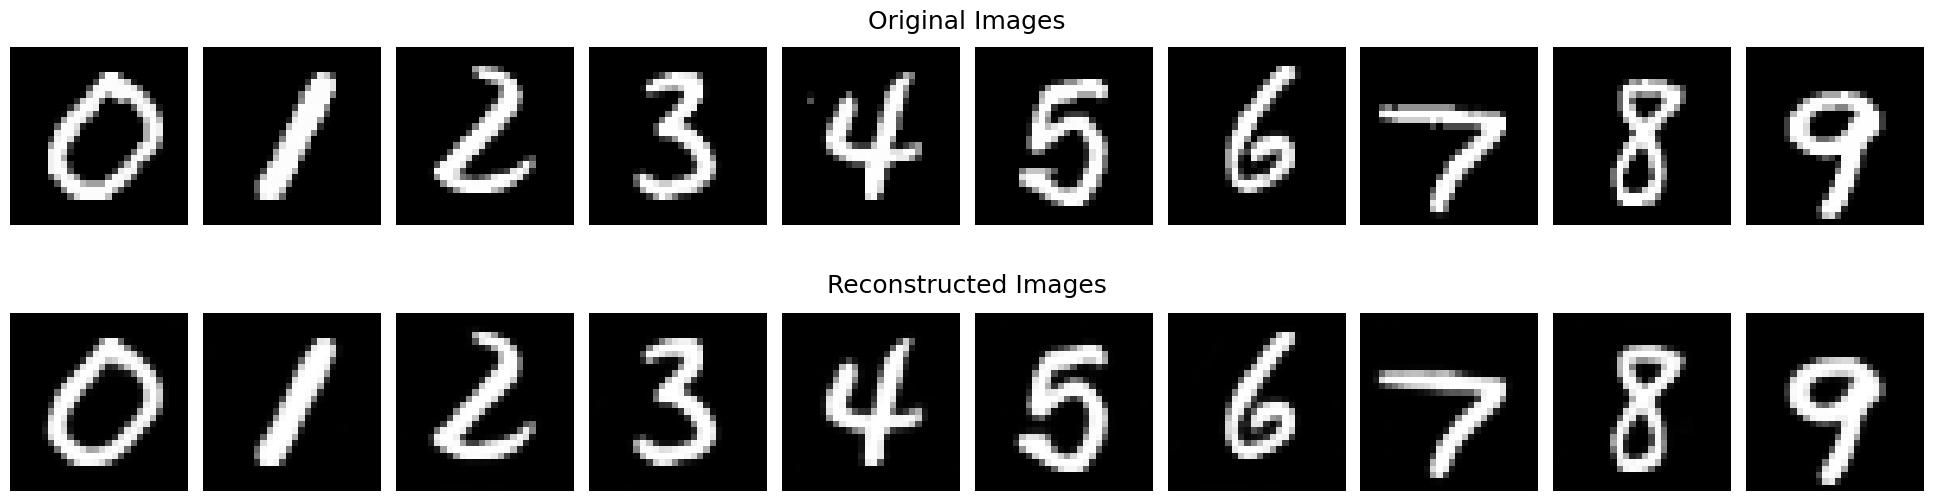

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step
Model 5 Test MSE: 0.002452


In [7]:
# Model 5: Convolutional Autoencoder
encoding_dim = 512

# Input needs to be reshaped to (28, 28, 1) for Conv2D
encoder_input = layers.Input(shape=(784,))
x = Reshape((28, 28, 1))(encoder_input)  

# Encoder: Conv2D + BatchNormalization + MaxPooling
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

# Flatten and create latent representation
x = Flatten()(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_5 = Model(encoder_input, latent, name='encoder_5')

# Decoder: Dense → Reshape
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(7 * 7 * 128, activation='relu')(decoder_input)
x = Reshape((7, 7, 128))(x)

# Decoder: Conv2D + BatchNormalization + UpSampling
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Flatten back to match input
decoder_output = Flatten()(x)

decoder_5 = Model(decoder_input, decoder_output, name='decoder_5')

# Autoencoder
autoencoder_5 = Model(encoder_input, decoder_5(encoder_5(encoder_input)), 
                      name='autoencoder_5_CNN')

# Compile with metrics
autoencoder_5.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=[dp.psnr, dp.ssim])

# Train
print("\nTraining Model 5 (Convolutional)...\n")
start_time = time.time()
history_5 = autoencoder_5.fit(x_train, x_train, epochs=30,
            batch_size=256, validation_split=0.4, verbose=1)
train_time_5 = time.time() - start_time
print(f"\nModel 5 Training Time: {train_time_5:.2f} seconds")

# Plot training history
dp.plot_history(history_5, "Model 5")

# Store validation loss and metrics
val_loss_5 = history_5.history['val_loss'][-1]
val_psnr_5 = history_5.history['psnr'][-1]
val_ssim_5 = history_5.history['ssim'][-1]
print(f"Model 5 Final Validation Loss: {val_loss_5:.6f}")
print(f"Model 5 Final Validation PSNR: {val_psnr_5:.6f}")
print(f"Model 5 Final Validation SSIM: {val_ssim_5:.6f}")

# Visualize reconstructions on test set
reconstructed_5 = autoencoder_5.predict(test_samples)
dp.plot_reconstructions(test_samples, reconstructed_5, n=10)

# Calculate test MSE
mse_5 = dp.calculate_mse(x_test, autoencoder_5.predict(x_test))
print(f"Model 5 Test MSE: {mse_5:.6f}")


#### **Model 6: PCA Reconstruction**
Traditional PCA for comparison with autoencoders' performances.

Applying PCA Reconstruction: 784 -> 154 -> 784 dimensions
Explained variance: 95.02%
Compressed training shape: (60000, 154)
Compressed test shape: (10000, 154)
Reconstructed training shape: (60000, 784)
Reconstructed test shape: (10000, 784)

PCA Reconstruction Time: 4.86 seconds


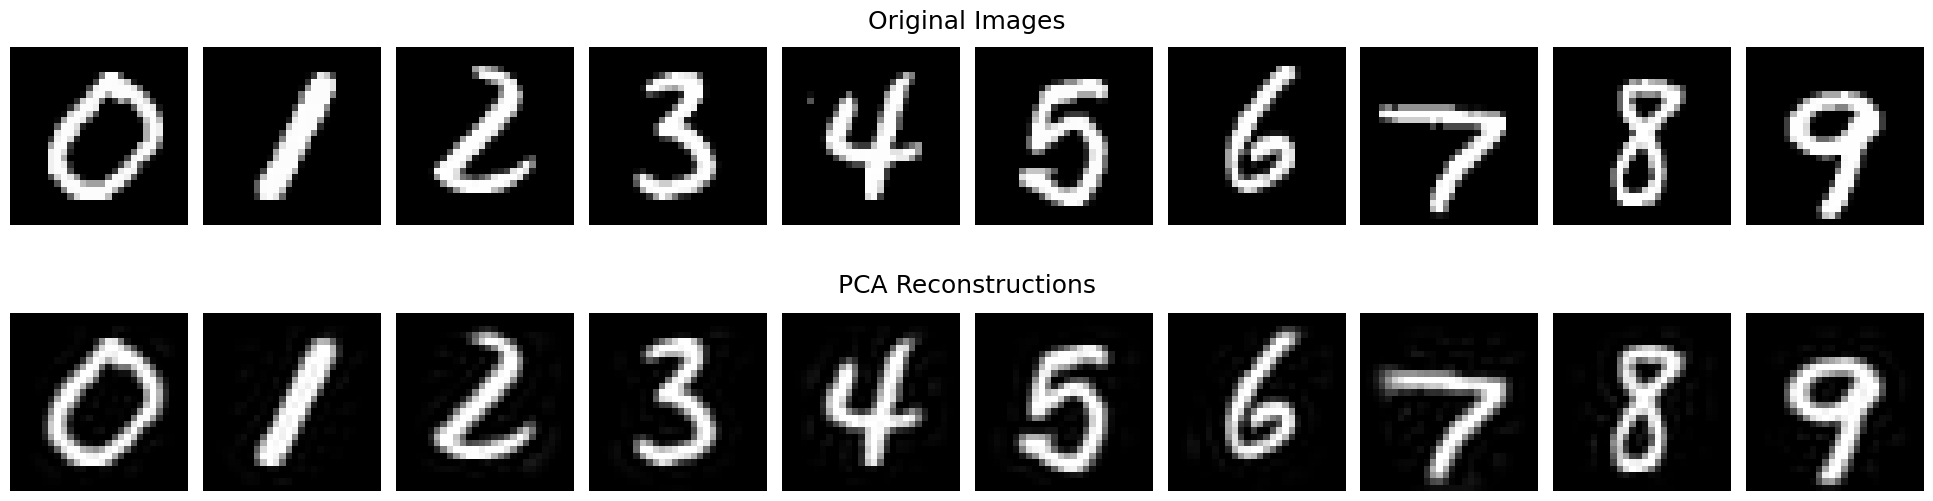


PCA Test MSE: 0.002632


In [8]:
# PCA Reconstruction
start_time = time.time()
x_train_pca, x_test_pca, n_components = dp.pca_reconstruction(x_train, x_test, n_components=0.95)
pca_time = time.time() - start_time
print(f"PCA Reconstruction Time: {pca_time:.2f} seconds")

# Visualize PCA reconstructions on test set
dp.plot_reconstructions(test_samples, x_test_pca[test_indices], n=10, title="PCA Reconstructions")

# Calculate PCA MSE
mse_pca = dp.calculate_mse(x_test, x_test_pca)
print(f"\nPCA Test MSE: {mse_pca:.6f}")

#### **Model Comparison Summary**
Compare all models and PCA.

MODEL COMPARISON
Model                               MSE          Encoding     Parameters      Training Time  
----------------------------------------------------------------------------------------------------
Model 1: Dense AE                   0.008539     32           209,968         46.50          
Model 2: Deep Dense AE (64)         0.005632     64           1,149,520       141.01         
Model 3: Deep Dense AE (128)        0.003495     128          1,132,944       139.50         
Model 4: Deep Dense with Metrics    0.003453     128          1,132,944       210.43         
Model 5: Conv                       0.002452     512          6,763,905       2705.37        
Model 6: PCA                        0.002632     154          0               4.86           



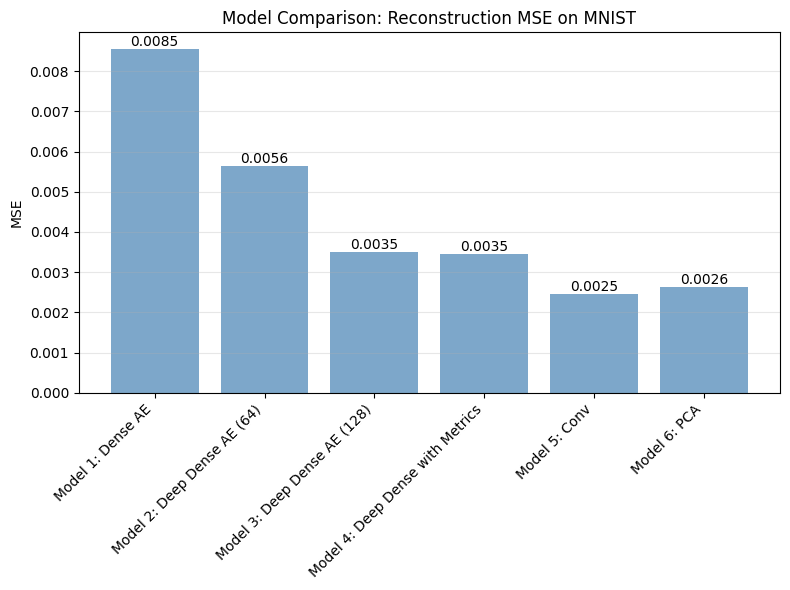

In [9]:
# Collect all results
results = [
    ("Model 1: Dense AE", mse_1, 32, autoencoder_1.count_params(), train_time_1),
    ("Model 2: Deep Dense AE (64)", mse_2, 64, autoencoder_2.count_params(), train_time_2),
    ("Model 3: Deep Dense AE (128)", mse_3, 128, autoencoder_3.count_params(), train_time_3),
    ("Model 4: Deep Dense with Metrics", mse_4, 128, autoencoder_4.count_params(), train_time_4),
    ("Model 5: Conv", mse_5, 512, autoencoder_5.count_params(), train_time_5),
    ("Model 6: PCA", mse_pca, 154, 0, pca_time)
]

# Print comparison table
dp.compare_models_table(results)

# Visualize MSE comparison
model_names = [r[0] for r in results]
mse_values = [r[1] for r in results]

plt.figure(figsize=(8, 6))
bars = plt.bar(range(len(model_names)), mse_values, color='steelblue', alpha=0.7)
plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
plt.ylabel('MSE')
plt.title('Model Comparison: Reconstruction MSE on MNIST')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{mse_values[i]:.4f}', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#### **CNN Classifier**
Compare classification accuracy between original and reconstructed test images.

In [10]:
# Create the CNN classifier
cnn_model = dp.build_digit_classifier()

# Get reconstructed test images from autoencoder_5
reconstructed_test = autoencoder_5.predict(x_test)

# Reshape for CNN input (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
reconstructed_test = reconstructed_test.reshape(-1, 28, 28, 1)

# Train the CNN on original training set
print("\nTraining CNN on original training set...\n")
cnn_history = cnn_model.fit(x_train, y_train, epochs=10,
            batch_size=128, validation_split=0.4, verbose=1)

# Evaluate on original test images
original_loss, original_accuracy = cnn_model.evaluate(x_test, y_test, verbose=0)

# Evaluate on reconstructed test images
reconstructed_loss, reconstructed_accuracy = cnn_model.evaluate(reconstructed_test, y_test, verbose=0)

print(f"\nTest Accuracy on Original Images: {original_accuracy:.4f}")
print(f"Test Accuracy on Reconstructed Images: {reconstructed_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step

Training CNN on original training set...

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.8773 - loss: 0.4051 - val_accuracy: 0.9713 - val_loss: 0.0906
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9654 - loss: 0.1162 - val_accuracy: 0.9800 - val_loss: 0.0613
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9752 - loss: 0.0843 - val_accuracy: 0.9838 - val_loss: 0.0523
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9800 - loss: 0.0672 - val_accuracy: 0.9858 - val_loss: 0.0475
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.9842 - loss: 0.0544 - val_accuracy: 0.9867 - val_loss: 0.0460
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9850 - loss: 0.0469 - val_accuracy: 0.9868 - val_loss: 0.0440
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9871 - loss: 0.0405 - val_accuracy: 0.9882 - val_loss: 0.0410
Epoch 8/